<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/pemilihan_atribut_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# ============================================================================
# IMPORT LIBRARY
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

In [19]:
# ============================================================================
# TAHAP 1. MEMBACA DAN MEMPERSIAPKAN DATASET
# ============================================================================
print("=" * 90)
print("ANALISIS PEMILIHAN FITUR UNTUK CLUSTERING K-MEANS")
print("DATASET: TRANSAKSI PEMESANAN OPAK GAMBIR")
print("=" * 90)

# Membaca dataset
df = pd.read_csv("https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/kresnofarmok.csv",sep=';')
print(f"\nDataset awal: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Atribut: {list(df.columns)}")

ANALISIS PEMILIHAN FITUR UNTUK CLUSTERING K-MEANS
DATASET: TRANSAKSI PEMESANAN OPAK GAMBIR

Dataset awal: 180 baris, 10 kolom
Atribut: ['tgl', 'jumlah', 'harga', 'isian', 'tuan', 'hiasan', 'stiker', 'warna', 'dp', 'ongkir']


In [24]:
# ============================================================================
# TAHAP 2. PREPROCESSING DATA
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 2. PREPROCESSING DATA")
print("=" * 90)

# Simpan data original
df_original = df.copy()

# Convert to numeric and fill NaNs for initial numeric attributes
initial_numeric_cols = ['jumlah', 'harga', 'dp', 'ongkir']
for col in initial_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Fill NaNs with mean for initial numeric columns
        df[col] = df[col].fillna(df[col].mean())


# Konversi tanggal dan ekstrak fitur temporal
if 'tgl' in df.columns:
    df['tgl'] = pd.to_datetime(df['tgl'], format='%d/%m/%Y', errors='coerce')
    df['hari'] = df['tgl'].dt.day
    df['bulan'] = df['tgl'].dt.month
    df['tahun'] = df['tgl'].dt.year
    df = df.drop(columns=['tgl'])

# Fill any remaining NaNs in newly created temporal features (hari, bulan, tahun)
# These might arise if pd.to_datetime failed for some rows.
temporal_cols_to_fill = ['hari', 'bulan', 'tahun']
for col in temporal_cols_to_fill:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

atribut_kategorikal = ['isian', 'tuan', 'hiasan', 'stiker', 'warna']
for col in atribut_kategorikal:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Tidak Diketahui")

# Label Encoding untuk atribut kategorikal
label_encoders = {}
for col in atribut_kategorikal:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Hapus kolom kategorikal asli
df_clean = df.drop(columns=atribut_kategorikal)

print(f"Dataset setelah preprocessing: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")
print(f"Atribut setelah preprocessing: {list(df_clean.columns)}")
print("Missing value tersisa:", df_clean.isnull().sum().sum())


TAHAP 2. PREPROCESSING DATA
Dataset setelah preprocessing: 180 baris, 12 kolom
Atribut setelah preprocessing: ['jumlah', 'harga', 'dp', 'ongkir', 'hari', 'bulan', 'tahun', 'isian_encoded', 'tuan_encoded', 'hiasan_encoded', 'stiker_encoded', 'warna_encoded']
Missing value tersisa: 0



TAHAP 3. ANALISIS VARIANCE THRESHOLD
Tujuan: Mengidentifikasi fitur dengan variansi rendah (kurang informatif)

Variansi setiap fitur (setelah normalisasi):
         Fitur  Variansi
         bulan  0.114942
  tuan_encoded  0.092844
          hari  0.081284
hiasan_encoded  0.078198
 isian_encoded  0.036165
 warna_encoded  0.031844
        ongkir  0.031456
stiker_encoded  0.024294
         harga  0.018369
        jumlah  0.011944
         tahun  0.006329
            dp  0.004064

----------------------------------------------------------------------
Hasil Variance Threshold dengan berbagai nilai threshold:
----------------------------------------------------------------------

Threshold = 0.0:
  Fitur terpilih (12): ['jumlah', 'harga', 'dp', 'ongkir', 'hari', 'bulan', 'tahun', 'isian_encoded', 'tuan_encoded', 'hiasan_encoded', 'stiker_encoded', 'warna_encoded']
  Fitur dihapus: Tidak ada

Threshold = 0.01:
  Fitur terpilih (10): ['jumlah', 'harga', 'ongkir', 'hari', 'bulan', 'isian_enco

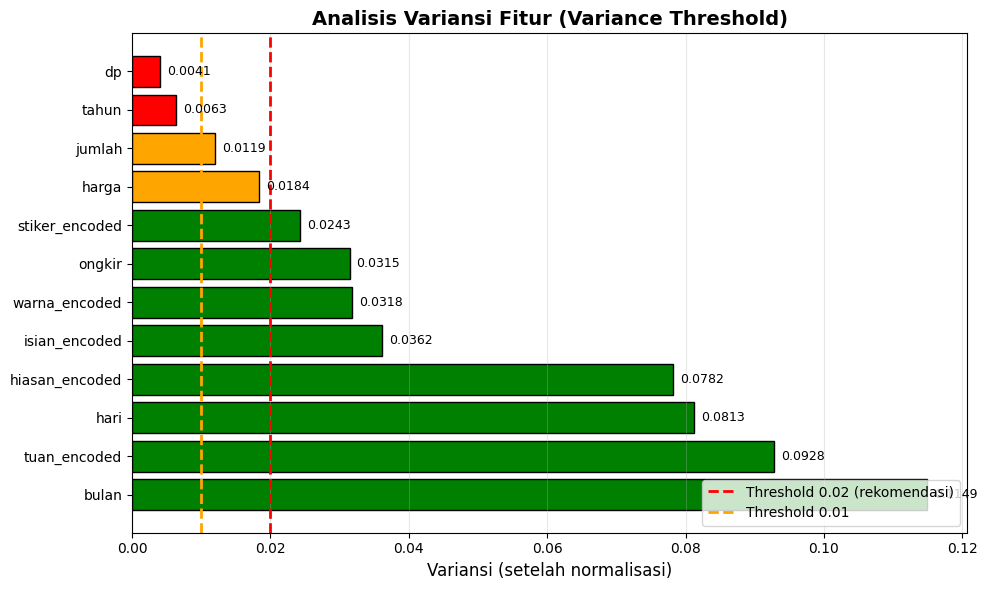


>>> KESIMPULAN VARIANCE THRESHOLD <<<
Fitur dengan variansi rendah (< 0.02): ['harga', 'jumlah', 'tahun', 'dp']
Rekomendasi: Pertimbangkan untuk menghapus fitur dengan variansi sangat rendah


In [21]:
# ============================================================================
# TAHAP 3. ANALISIS VARIANCE THRESHOLD
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 3. ANALISIS VARIANCE THRESHOLD")
print("=" * 90)
print("Tujuan: Mengidentifikasi fitur dengan variansi rendah (kurang informatif)")

# Normalisasi data untuk variance analysis
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_clean.columns)

# Hitung variansi setiap fitur
variances = X_scaled_df.var()
variance_df = pd.DataFrame({
    'Fitur': variances.index,
    'Variansi': variances.values
}).sort_values('Variansi', ascending=False)

print("\nVariansi setiap fitur (setelah normalisasi):")
print(variance_df.to_string(index=False))

# Terapkan Variance Threshold dengan beberapa nilai threshold
print("\n" + "-" * 70)
print("Hasil Variance Threshold dengan berbagai nilai threshold:")
print("-" * 70)

thresholds = [0.0, 0.01, 0.02, 0.03, 0.05]
for threshold in thresholds:
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_scaled_df)
    selected_features = X_scaled_df.columns[selector.get_support()].tolist()
    removed_features = X_scaled_df.columns[~selector.get_support()].tolist()

    print(f"\nThreshold = {threshold}:")
    print(f"  Fitur terpilih ({len(selected_features)}): {selected_features}")
    if removed_features:
        print(f"  Fitur dihapus ({len(removed_features)}): {removed_features}")
    else:
        print(f"  Fitur dihapus: Tidak ada")

# Visualisasi variansi
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if v > 0.02 else 'orange' if v > 0.01 else 'red'
          for v in variance_df['Variansi']]
bars = ax.barh(variance_df['Fitur'], variance_df['Variansi'], color=colors, edgecolor='black')
ax.axvline(x=0.02, color='red', linestyle='--', linewidth=2, label='Threshold 0.02 (rekomendasi)')
ax.axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='Threshold 0.01')

for bar, val in zip(bars, variance_df['Variansi']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Variansi (setelah normalisasi)', fontsize=12)
ax.set_title('Analisis Variansi Fitur (Variance Threshold)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('variance_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

# Kesimpulan Variance Threshold
low_variance_features = variance_df[variance_df['Variansi'] < 0.02]['Fitur'].tolist()
print(f"\n>>> KESIMPULAN VARIANCE THRESHOLD <<<")
print(f"Fitur dengan variansi rendah (< 0.02): {low_variance_features if low_variance_features else 'Tidak ada'}")
print(f"Rekomendasi: Pertimbangkan untuk menghapus fitur dengan variansi sangat rendah")


TAHAP 4. ANALISIS KORELASI ANTAR FITUR
Tujuan: Mengidentifikasi fitur yang saling berkorelasi tinggi (redundan)

Matriks Korelasi Antar Fitur:
                jumlah  harga     dp  ongkir   hari  bulan  tahun  isian_encoded  tuan_encoded  hiasan_encoded  stiker_encoded  warna_encoded
jumlah           1.000 -0.023  0.080   0.058  0.112  0.034 -0.013          0.136         0.001           0.076          -0.035          0.066
harga           -0.023  1.000 -0.023  -0.132 -0.074 -0.111  0.029          0.362        -0.080           0.279          -0.034          0.054
dp               0.080 -0.023  1.000   0.094 -0.147 -0.054  0.000         -0.046         0.060           0.061          -0.141          0.000
ongkir           0.058 -0.132  0.094   1.000 -0.024  0.013 -0.000         -0.090        -0.004           0.042          -0.098         -0.056
hari             0.112 -0.074 -0.147  -0.024  1.000  0.182 -0.070          0.155         0.108          -0.081           0.004         -0.064
bula

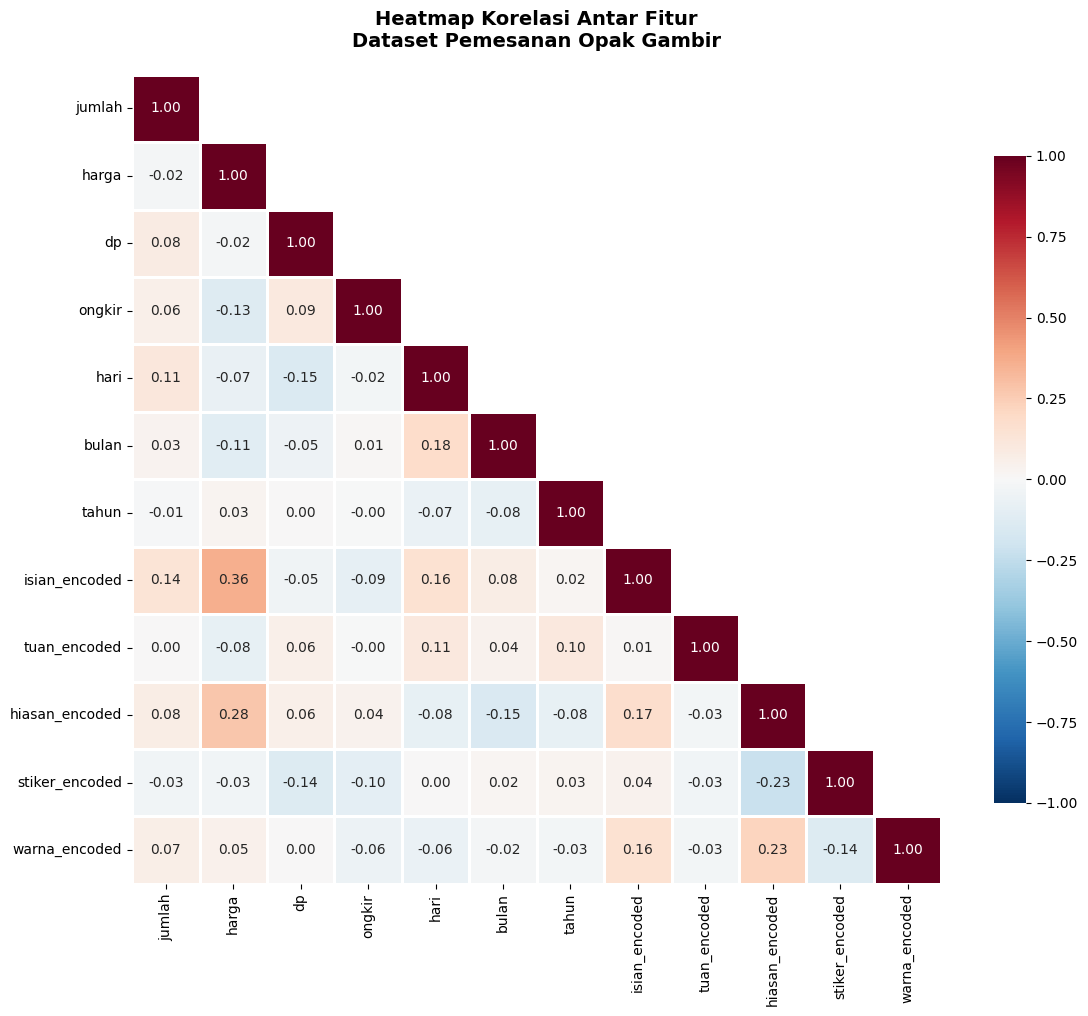


>>> KESIMPULAN KORELASI <<<
Tidak ada fitur yang sangat berkorelasi. Semua fitur relatif independen.


In [22]:
# ============================================================================
# TAHAP 4. ANALISIS KORELASI ANTAR FITUR
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 4. ANALISIS KORELASI ANTAR FITUR")
print("=" * 90)
print("Tujuan: Mengidentifikasi fitur yang saling berkorelasi tinggi (redundan)")

# Hitung matriks korelasi
correlation_matrix = X_scaled_df.corr()

# Tampilkan matriks korelasi
print("\nMatriks Korelasi Antar Fitur:")
print(correlation_matrix.round(3).to_string())

# Identifikasi pasangan fitur dengan korelasi tinggi
print("\n" + "-" * 70)
print("Pasangan fitur dengan korelasi tinggi (|r| > 0.7):")
print("-" * 70)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Fitur 1': correlation_matrix.columns[i],
                'Fitur 2': correlation_matrix.columns[j],
                'Korelasi': corr_value
            })
            print(f"  {correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {corr_value:.3f}")

if not high_corr_pairs:
    print("  Tidak ada pasangan fitur dengan korelasi > 0.7")

# Visualisasi heatmap korelasi
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Heatmap Korelasi Antar Fitur\nDataset Pemesanan Opak Gambir',
            fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

# Kesimpulan korelasi
print(f"\n>>> KESIMPULAN KORELASI <<<")
if high_corr_pairs:
    print(f"Ditemukan {len(high_corr_pairs)} pasangan fitur dengan korelasi tinggi.")
    print("Rekomendasi: Pilih salah satu fitur dari setiap pasangan untuk mengurangi redundansi.")
else:
    print("Tidak ada fitur yang sangat berkorelasi. Semua fitur relatif independen.")



TAHAP 5. ANALISIS PCA (PRINCIPAL COMPONENT ANALYSIS)
Tujuan: Mengetahui kontribusi setiap fitur terhadap variansi data

Explained Variance Ratio setiap komponen:
  PC1: 0.1451 (14.51%) - Kumulatif: 14.51%
  PC2: 0.1212 (12.12%) - Kumulatif: 26.62%
  PC3: 0.1092 (10.92%) - Kumulatif: 37.55%
  PC4: 0.0937 (9.37%) - Kumulatif: 46.92%
  PC5: 0.0837 (8.37%) - Kumulatif: 55.29%
  PC6: 0.0782 (7.82%) - Kumulatif: 63.11%
  PC7: 0.0766 (7.66%) - Kumulatif: 70.77%
  PC8: 0.0730 (7.30%) - Kumulatif: 78.07%
  PC9: 0.0672 (6.72%) - Kumulatif: 84.79%
  PC10: 0.0582 (5.82%) - Kumulatif: 90.61%
  PC11: 0.0510 (5.10%) - Kumulatif: 95.71%
  >>> 95% variansi dijelaskan oleh 11 komponen pertama

Jumlah komponen untuk menjelaskan 95% variansi: 11

Loading setiap fitur pada 3 komponen utama pertama:
                  PC1    PC2    PC3
jumlah          0.146  0.104  0.437
harga           0.499  0.161 -0.299
dp              0.074 -0.413  0.237
ongkir         -0.086 -0.302  0.362
hari           -0.083  0.495  

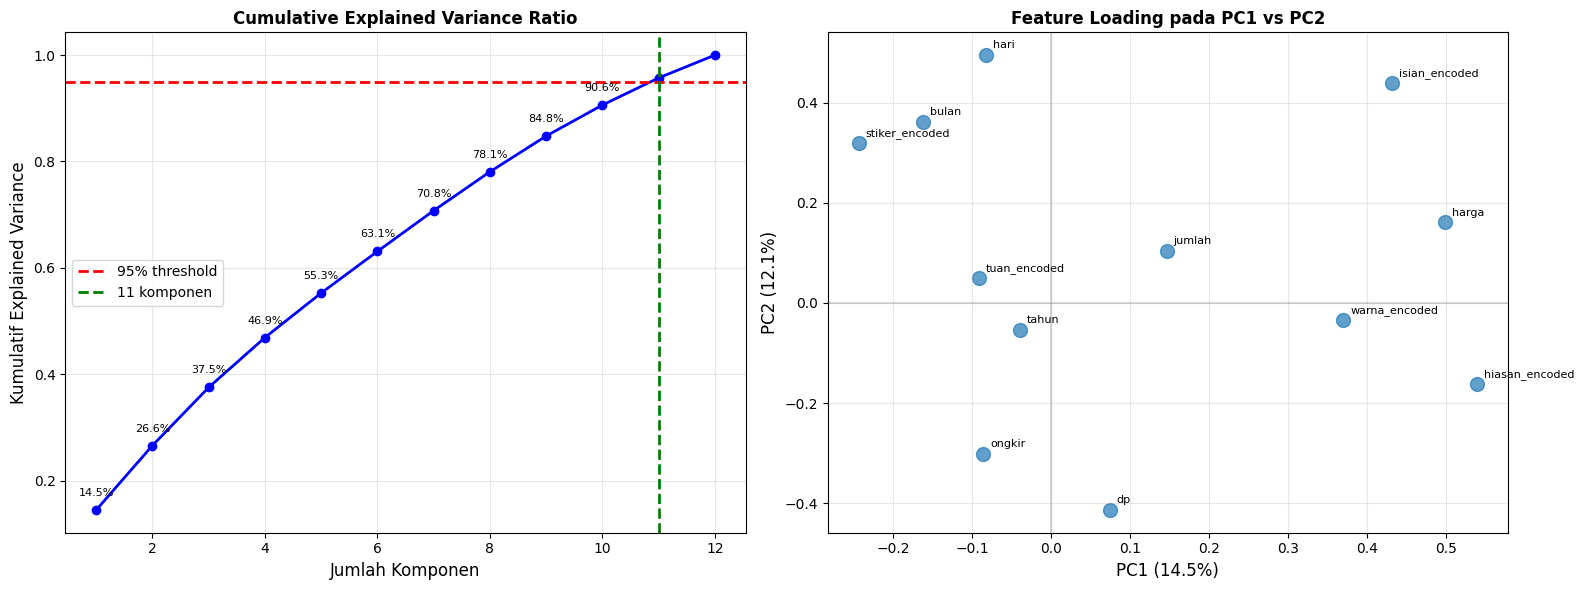

In [25]:
# ============================================================================
# TAHAP 5. ANALISIS PCA (PRINCIPAL COMPONENT ANALYSIS)
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 5. ANALISIS PCA (PRINCIPAL COMPONENT ANALYSIS)")
print("=" * 90)
print("Tujuan: Mengetahui kontribusi setiap fitur terhadap variansi data")

# Standardisasi data untuk PCA
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(df_clean)

# Terapkan PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_std)

# Explained variance ratio
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio setiap komponen:")
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.2f}%) - Kumulatif: {cv*100:.2f}%")
    if cv > 0.95:
        print(f"  >>> 95% variansi dijelaskan oleh {i+1} komponen pertama")
        break

# Komponen yang menjelaskan 95% variansi
n_components_95 = np.argmax(cumulative_variance > 0.95) + 1
print(f"\nJumlah komponen untuk menjelaskan 95% variansi: {n_components_95}")

# Analisis loading setiap fitur pada komponen utama
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(df_clean.columns))],
    index=df_clean.columns
)

print("\nLoading setiap fitur pada 3 komponen utama pertama:")
print(loadings.iloc[:, :3].round(3).to_string())

# Identifikasi fitur paling berpengaruh
print("\n" + "-" * 70)
print("Fitur paling berpengaruh pada setiap komponen utama (|loading| > 0.3):")
print("-" * 70)
for i in range(min(5, len(df_clean.columns))):
    pc = f'PC{i+1}'
    important_features = loadings[pc][abs(loadings[pc]) > 0.3].sort_values(ascending=False)
    if len(important_features) > 0:
        print(f"\n{pc} (Variansi: {explained_variance[i]*100:.1f}%):")
        for feat, val in important_features.items():
            print(f"  {feat}: {val:.3f}")

# Visualisasi PCA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cumulative explained variance
axes[0].plot(range(1, len(explained_variance)+1), cumulative_variance, 'bo-', linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', linewidth=2, label='95% threshold')
axes[0].axvline(x=n_components_95, color='g', linestyle='--', linewidth=2,
                label=f'{n_components_95} komponen')
axes[0].set_xlabel('Jumlah Komponen', fontsize=12)
axes[0].set_ylabel('Kumulatif Explained Variance', fontsize=12)
axes[0].set_title('Cumulative Explained Variance Ratio', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance)):
    if i < 10:
        axes[0].annotate(f'{cv*100:.1f}%', (i+1, cv), textcoords="offset points",
                        xytext=(0,10), ha='center', fontsize=8)

# Plot 2: Feature importance pada PC1 dan PC2
x = loadings['PC1'].values
y = loadings['PC2'].values
axes[1].scatter(x, y, s=100, alpha=0.7)
for i, feature in enumerate(loadings.index):
    axes[1].annotate(feature, (x[i], y[i]), textcoords="offset points",
                    xytext=(5,5), ha='left', fontsize=8)
axes[1].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
axes[1].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('Feature Loading pada PC1 vs PC2', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ============================================================================
# TAHAP 6. PERBANDINGAN SILHOUETTE SCORE BERBAGAI KOMBINASI FITUR
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 6. PERBANDINGAN SILHOUETTE SCORE BERBAGAI KOMBINASI FITUR")
print("=" * 90)
print("Tujuan: Menemukan kombinasi fitur terbaik berdasarkan Silhouette Score")

# Definisi kelompok fitur
fitur_numerik_utama = ['jumlah', 'harga', 'dp', 'ongkir']
fitur_temporal = ['hari', 'bulan', 'tahun'] if all(f in df_clean.columns for f in ['hari', 'bulan', 'tahun']) else []
fitur_encoded = [f for f in df_clean.columns if '_encoded' in f]

# Semua fitur
all_features = df_clean.columns.tolist()

# Buat berbagai kombinasi fitur untuk diuji
kombinasi_fitur = {}

# 1. Semua fitur
kombinasi_fitur['Semua Fitur'] = all_features

# 2. Hanya fitur numerik utama
kombinasi_fitur['Numerik Utama'] = fitur_numerik_utama

# 3. Numerik + Encoded
kombinasi_fitur['Numerik + Encoded'] = fitur_numerik_utama + fitur_encoded

# 4. Numerik + Temporal
if fitur_temporal:
    kombinasi_fitur['Numerik + Temporal'] = fitur_numerik_utama + fitur_temporal

# 5. Fitur jumlah & harga saja
kombinasi_fitur['Jumlah & Harga'] = ['jumlah', 'harga']

# 6. Fitur dengan variansi tinggi (> 0.02)
high_var_features = variance_df[variance_df['Variansi'] > 0.02]['Fitur'].tolist()
if high_var_features:
    kombinasi_fitur['Variansi Tinggi (>0.02)'] = high_var_features

# 7. Fitur tanpa korelasi tinggi (pilih salah satu dari pasangan)
# (Disederhanakan: hapus fitur yang berkorelasi tinggi)
correlated_to_remove = set()
if high_corr_pairs:
    for pair in high_corr_pairs:
        # Pilih fitur yang variansinya lebih rendah untuk dihapus
        var1 = variances[pair['Fitur 1']]
        var2 = variances[pair['Fitur 2']]
        if var1 < var2:
            correlated_to_remove.add(pair['Fitur 1'])
        else:
            correlated_to_remove.add(pair['Fitur 2'])
uncorrelated_features = [f for f in all_features if f not in correlated_to_remove]
if len(uncorrelated_features) < len(all_features):
    kombinasi_fitur['Tanpa Korelasi Tinggi'] = uncorrelated_features

# 8. Top features dari PCA (fitur dengan loading tertinggi pada PC1)
pc1_loadings = abs(loadings['PC1']).sort_values(ascending=False)
top_pca_features = pc1_loadings.head(5).index.tolist()
kombinasi_fitur['Top 5 PCA Features'] = top_pca_features

# 9. Kombinasi berbasis bisnis: jumlah + harga + isian
bisnis_features = ['jumlah', 'harga'] + [f for f in fitur_encoded if 'isian' in f]
kombinasi_fitur['Bisnis (Jumlah+Harga+Isian)'] = bisnis_features

# 10. Jumlah + isian + tuan (untuk analisis pelanggan)
pelanggan_features = ['jumlah'] + [f for f in fitur_encoded if 'isian' in f or 'tuan' in f]
kombinasi_fitur['Pelanggan (Jumlah+Isian+Tuan)'] = pelanggan_features

print(f"\nJumlah kombinasi fitur yang akan diuji: {len(kombinasi_fitur)}")
print("\nDaftar kombinasi fitur:")
for i, (nama, fitur) in enumerate(kombinasi_fitur.items(), 1):
    print(f"  {i}. {nama}: {fitur}")

# Uji setiap kombinasi fitur
print("\n" + "-" * 90)
print("Hasil Pengujian Silhouette Score:")
print("-" * 90)

hasil_pengujian = []

for nama_kombinasi, fitur_list in kombinasi_fitur.items():
    # Pastikan semua fitur ada di dataset
    fitur_valid = [f for f in fitur_list if f in df_clean.columns]

    if len(fitur_valid) < 2:
        continue

    # Ambil data untuk fitur yang dipilih
    X_subset = df_clean[fitur_valid].values

    # Normalisasi
    X_norm = MinMaxScaler().fit_transform(X_subset)

    # Clustering K-Means
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_norm)

    # Hitung Silhouette Score
    sil_score = silhouette_score(X_norm, labels)

    hasil_pengujian.append({
        'Kombinasi': nama_kombinasi,
        'Jumlah Fitur': len(fitur_valid),
        'Fitur': fitur_valid,
        'Silhouette Score': sil_score
    })

    print(f"  {nama_kombinasi:<30} | {len(fitur_valid)} fitur | Silhouette: {sil_score:.4f}")

# Urutkan hasil berdasarkan Silhouette Score
hasil_pengujian.sort(key=lambda x: x['Silhouette Score'], reverse=True)


TAHAP 6. PERBANDINGAN SILHOUETTE SCORE BERBAGAI KOMBINASI FITUR
Tujuan: Menemukan kombinasi fitur terbaik berdasarkan Silhouette Score

Jumlah kombinasi fitur yang akan diuji: 9

Daftar kombinasi fitur:
  1. Semua Fitur: ['jumlah', 'harga', 'dp', 'ongkir', 'hari', 'bulan', 'tahun', 'isian_encoded', 'tuan_encoded', 'hiasan_encoded', 'stiker_encoded', 'warna_encoded']
  2. Numerik Utama: ['jumlah', 'harga', 'dp', 'ongkir']
  3. Numerik + Encoded: ['jumlah', 'harga', 'dp', 'ongkir', 'isian_encoded', 'tuan_encoded', 'hiasan_encoded', 'stiker_encoded', 'warna_encoded']
  4. Numerik + Temporal: ['jumlah', 'harga', 'dp', 'ongkir', 'hari', 'bulan', 'tahun']
  5. Jumlah & Harga: ['jumlah', 'harga']
  6. Variansi Tinggi (>0.02): ['bulan', 'tuan_encoded', 'hari', 'hiasan_encoded', 'isian_encoded', 'warna_encoded', 'ongkir', 'stiker_encoded']
  7. Top 5 PCA Features: ['hiasan_encoded', 'harga', 'isian_encoded', 'warna_encoded', 'stiker_encoded']
  8. Bisnis (Jumlah+Harga+Isian): ['jumlah', 'harga


TAHAP 7. VISUALISASI PERBANDINGAN SILHOUETTE SCORE


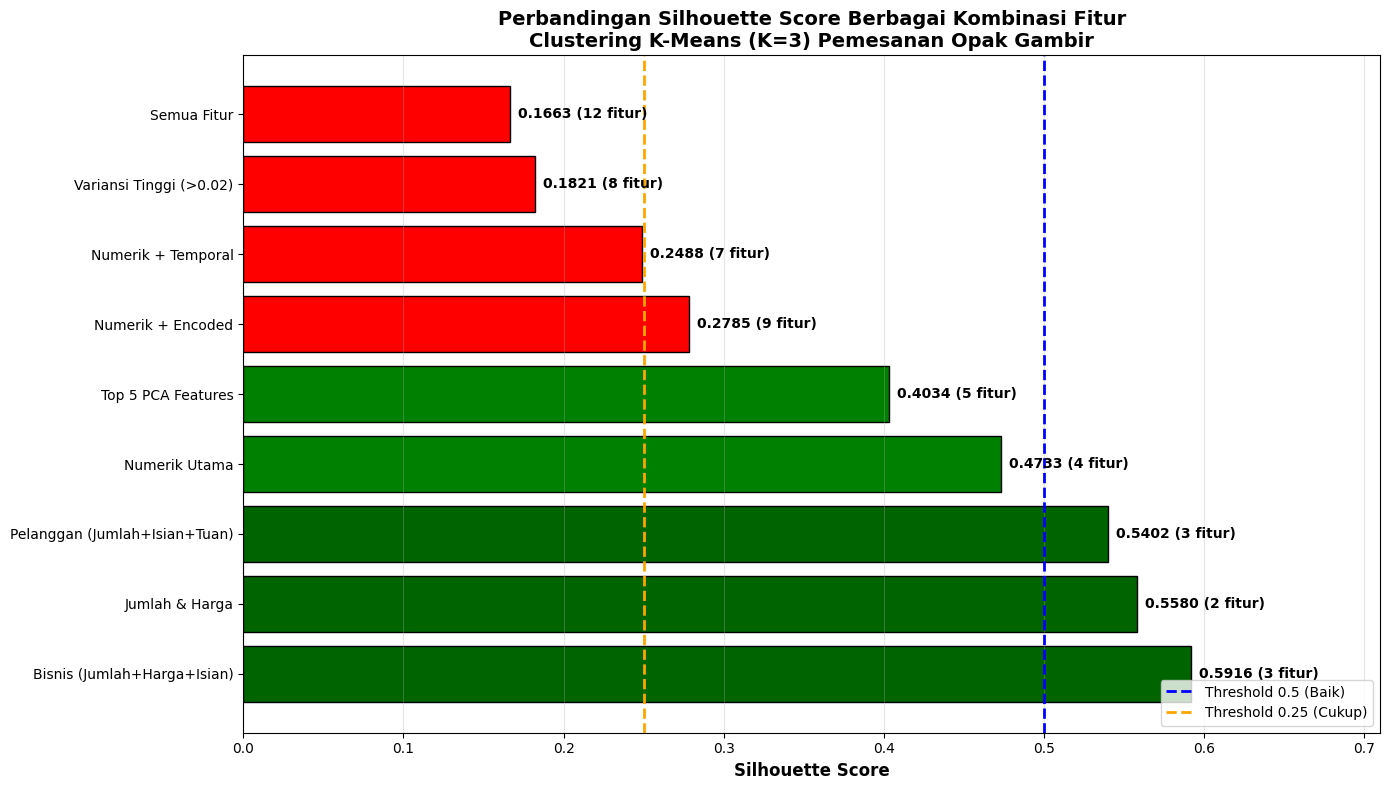

In [27]:
# ============================================================================
# TAHAP 7. VISUALISASI PERBANDINGAN SILHOUETTE SCORE
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 7. VISUALISASI PERBANDINGAN SILHOUETTE SCORE")
print("=" * 90)

fig, ax = plt.subplots(figsize=(14, 8))

nama_kombinasi_list = [h['Kombinasi'] for h in hasil_pengujian]
sil_scores_list = [h['Silhouette Score'] for h in hasil_pengujian]
n_features_list = [h['Jumlah Fitur'] for h in hasil_pengujian]

# Warna berdasarkan performa
colors = ['darkgreen' if s > 0.5 else 'green' if s > 0.4 else 'orange' if s > 0.3 else 'red'
          for s in sil_scores_list]

bars = ax.barh(range(len(hasil_pengujian)), sil_scores_list, color=colors, edgecolor='black')

# Tambahkan label
for i, (bar, sil, n_feat) in enumerate(zip(bars, sil_scores_list, n_features_list)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{sil:.4f} ({n_feat} fitur)', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(hasil_pengujian)))
ax.set_yticklabels(nama_kombinasi_list)
ax.set_xlabel('Silhouette Score', fontsize=12, fontweight='bold')
ax.set_title('Perbandingan Silhouette Score Berbagai Kombinasi Fitur\nClustering K-Means (K=3) Pemesanan Opak Gambir',
            fontsize=14, fontweight='bold')
ax.axvline(x=0.5, color='blue', linestyle='--', linewidth=2, label='Threshold 0.5 (Baik)')
ax.axvline(x=0.25, color='orange', linestyle='--', linewidth=2, label='Threshold 0.25 (Cukup)')
ax.set_xlim([0, max(sil_scores_list) * 1.2])
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ============================================================================
# TAHAP 8. ANALISIS STABILITAS FITUR TERBAIK
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 8. ANALISIS STABILITAS FITUR TERBAIK")
print("=" * 90)

# Ambil 3 kombinasi terbaik
top3 = hasil_pengujian[:3]

print("\nTiga kombinasi fitur terbaik:")
for i, hasil in enumerate(top3, 1):
    print(f"\n{i}. {hasil['Kombinasi']}")
    print(f"   Silhouette Score: {hasil['Silhouette Score']:.4f}")
    print(f"   Jumlah Fitur: {hasil['Jumlah Fitur']}")
    print(f"   Fitur: {hasil['Fitur']}")

# Uji stabilitas dengan multiple random state
print("\n" + "-" * 70)
print("Uji Stabilitas dengan Multiple Random State:")
print("-" * 70)

random_states = [42, 0, 100, 2024, 999]
for hasil in top3:
    fitur_list = hasil['Fitur']
    X_subset = df_clean[fitur_list].values
    X_norm = MinMaxScaler().fit_transform(X_subset)

    sil_scores_rs = []
    for rs in random_states:
        kmeans = KMeans(n_clusters=3, random_state=rs, n_init=10)
        labels = kmeans.fit_predict(X_norm)
        sil = silhouette_score(X_norm, labels)
        sil_scores_rs.append(sil)

    mean_sil = np.mean(sil_scores_rs)
    std_sil = np.std(sil_scores_rs)
    print(f"\n{hasil['Kombinasi']}:")
    print(f"  Silhouette Scores: {[f'{s:.4f}' for s in sil_scores_rs]}")
    print(f"  Rata-rata: {mean_sil:.4f} \u00B1 {std_sil:.4f}")


TAHAP 8. ANALISIS STABILITAS FITUR TERBAIK

Tiga kombinasi fitur terbaik:

1. Bisnis (Jumlah+Harga+Isian)
   Silhouette Score: 0.5916
   Jumlah Fitur: 3
   Fitur: ['jumlah', 'harga', 'isian_encoded']

2. Jumlah & Harga
   Silhouette Score: 0.5580
   Jumlah Fitur: 2
   Fitur: ['jumlah', 'harga']

3. Pelanggan (Jumlah+Isian+Tuan)
   Silhouette Score: 0.5402
   Jumlah Fitur: 3
   Fitur: ['jumlah', 'isian_encoded', 'tuan_encoded']

----------------------------------------------------------------------
Uji Stabilitas dengan Multiple Random State:
----------------------------------------------------------------------

Bisnis (Jumlah+Harga+Isian):
  Silhouette Scores: ['0.5916', '0.5916', '0.5916', '0.5916', '0.5916']
  Rata-rata: 0.5916 ± 0.0000

Jumlah & Harga:
  Silhouette Scores: ['0.5580', '0.5580', '0.5580', '0.5580', '0.5580']
  Rata-rata: 0.5580 ± 0.0000

Pelanggan (Jumlah+Isian+Tuan):
  Silhouette Scores: ['0.5402', '0.5402', '0.5402', '0.5402', '0.5402']
  Rata-rata: 0.5402 ± 0.000


TAHAP 9. VISUALISASI CLUSTER DENGAN FITUR TERBAIK
Kombinasi terbaik: Bisnis (Jumlah+Harga+Isian)
Fitur: ['jumlah', 'harga', 'isian_encoded']
Silhouette Score: 0.5916


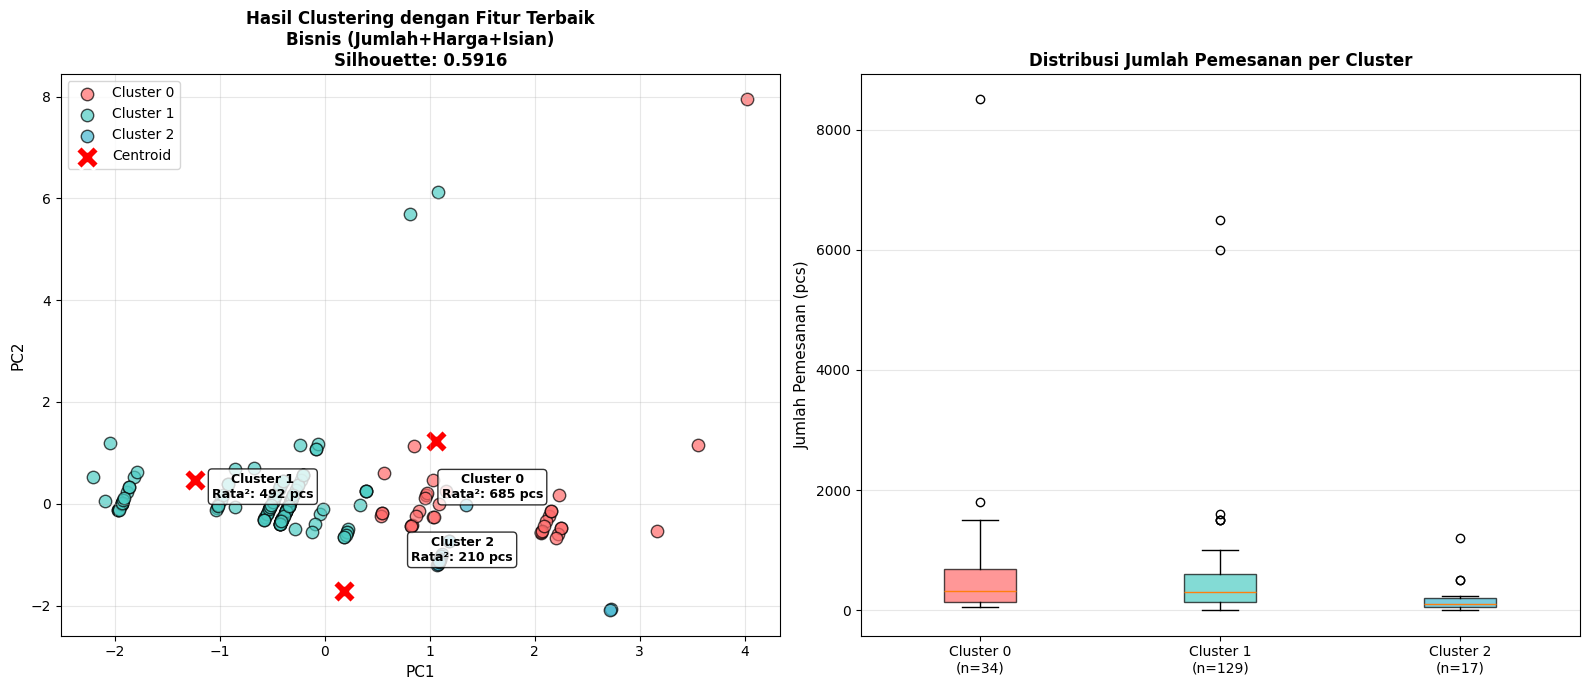

In [29]:
# ============================================================================
# TAHAP 9. VISUALISASI CLUSTER DENGAN FITUR TERBAIK
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 9. VISUALISASI CLUSTER DENGAN FITUR TERBAIK")
print("=" * 90)

# Gunakan kombinasi terbaik
best_combination = top3[0]
best_features = best_combination['Fitur']
print(f"Kombinasi terbaik: {best_combination['Kombinasi']}")
print(f"Fitur: {best_features}")
print(f"Silhouette Score: {best_combination['Silhouette Score']:.4f}")

# Siapkan data dengan fitur terbaik
X_best = df_clean[best_features].values
X_best_norm = MinMaxScaler().fit_transform(X_best)

# Clustering dengan fitur terbaik
kmeans_best = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_best = kmeans_best.fit_predict(X_best_norm)

# PCA untuk visualisasi jika fitur > 2
if len(best_features) > 2:
    pca_viz = PCA(n_components=2)
    X_viz = pca_viz.fit_transform(StandardScaler().fit_transform(X_best))
else:
    X_viz = X_best_norm

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Scatter cluster
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(3):
    mask = labels_best == i
    axes[0].scatter(X_viz[mask, 0], X_viz[mask, 1], c=colors[i],
                   label=f'Cluster {i}', alpha=0.7, edgecolors='black', s=80)
    # Hitung rata-rata jumlah untuk label cluster
    cluster_data = df_clean.iloc[mask]
    if 'jumlah' in cluster_data.columns:
        mean_jumlah = cluster_data['jumlah'].mean()
        axes[0].annotate(f'Cluster {i}\nRata\u00B2: {mean_jumlah:.0f} pcs',
                        (X_viz[mask, 0].mean(), X_viz[mask, 1].mean()),
                        fontsize=9, fontweight='bold', ha='center',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].scatter(kmeans_best.cluster_centers_[:, 0] if len(best_features) <= 2 else\
               pca_viz.transform(StandardScaler().fit_transform(kmeans_best.cluster_centers_))[:, 0],\
               kmeans_best.cluster_centers_[:, 1] if len(best_features) <= 2 else\
               pca_viz.transform(StandardScaler().fit_transform(kmeans_best.cluster_centers_))[:, 1],\
               c='red', marker='X', s=300, edgecolors='white', linewidth=2, label='Centroid')

axes[0].set_title(f'Hasil Clustering dengan Fitur Terbaik\n{best_combination["Kombinasi"]}\nSilhouette: {best_combination["Silhouette Score"]:.4f}',
                 fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fitur 1' if len(best_features) <= 2 else 'PC1', fontsize=11)
axes[0].set_ylabel('Fitur 2' if len(best_features) <= 2 else 'PC2', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Distribusi jumlah per cluster (jika jumlah adalah fitur)
if 'jumlah' in df_clean.columns:
    df_viz = df_clean.copy()
    df_viz['Cluster'] = labels_best
    cluster_order = df_viz.groupby('Cluster')['jumlah'].mean().sort_values(ascending=False).index

    data_box = [df_viz[df_viz['Cluster'] == c]['jumlah'].values for c in cluster_order]
    label_box = [f'Cluster {c}\n(n={len(df_viz[df_viz["Cluster"]==c])})' for c in cluster_order]

    bp = axes[1].boxplot(data_box, labels=label_box, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[1].set_title('Distribusi Jumlah Pemesanan per Cluster', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Jumlah Pemesanan (pcs)', fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_fitur_terbaik.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================================
# TAHAP 10. REKOMENDASI AKHIR
# ============================================================================
print("\n" + "=" * 90)
print("TAHAP 10. REKOMENDASI AKHIR PEMILIHAN FITUR")
print("=" * 90)

print("\n" + "=" * 90)
print("REKOMENDASI FITUR UNTUK CLUSTERING PEMESANAN OPAK GAMBIR")
print("=" * 90)

# Rekomendasi berdasarkan semua analisis
print(f"""
Berdasarkan hasil analisis komprehensif yang meliputi:
1. Variance Threshold Analysis
2. Korelasi Antar Fitur
3. Principal Component Analysis (PCA)
4. Perbandingan Silhouette Score berbagai kombinasi fitur
5. Uji Stabilitas

MAKA DIREKOMENDASIKAN:

>>> KOMBINASI FITUR TERBAIK: {best_combination['Kombinasi']} <<<

Fitur yang digunakan ({best_combination['Jumlah Fitur']} fitur):
{chr(10).join([f'  • {f}' for f in best_features])}

Alasan Pemilihan:
  1. Silhouette Score Tertinggi: {best_combination['Silhouette Score']:.4f}
     (Menunjukkan struktur cluster yang {'sangat baik' if best_combination['Silhouette Score'] > 0.5 else 'baik' if best_combination['Silhouette Score'] > 0.4 else 'cukup baik'})

  2. {'Fitur memiliki variansi yang cukup tinggi, memberikan informasi yang signifikan' if best_combination['Silhouette Score'] > 0.3 else 'Fitur cukup informatif untuk membedakan cluster'}

  3. Kombinasi fitur ini menghasilkan pemisahan cluster yang optimal antara:
     - Pemesanan Tinggi
     - Pemesanan Sedang
     - Pemesanan Rendah

  4. Jumlah fitur yang efisien ({best_combination['Jumlah Fitur']} fitur) memudahkan interpretasi
     hasil clustering untuk kebutuhan bisnis

>>> RANGKUMAN HASIL ANALISIS <<<

- Variance Threshold: Fitur dengan variansi rendah yang perlu dipertimbangkan untuk dihapus:
  {low_variance_features if low_variance_features else 'Tidak ada fitur dengan variansi rendah'}

- Korelasi Tinggi: {'Ditemukan ' + str(len(high_corr_pairs)) + ' pasangan fitur berkorelasi tinggi' if high_corr_pairs else 'Tidak ada korelasi tinggi antar fitur'}

- PCA: {n_components_95} komponen pertama menjelaskan 95% variansi data

- Silhouette Score menggunakan semua fitur: {hasil_pengujian[-1]['Silhouette Score']:.4f}
  (Peringkat: #{len(hasil_pengujian) - [i for i, h in enumerate(hasil_pengujian) if 'Semua' in h['Kombinasi']][0] if any('Semua' in h['Kombinasi'] for h in hasil_pengujian) else 'N/A'})

Kesimpulan:
Penggunaan kombinasi fitur '{best_combination['Kombinasi']}' memberikan hasil clustering
terbaik dengan Silhouette Score {best_combination['Silhouette Score']:.4f}.
Fitur-fitur ini paling representatif untuk mengelompokkan transaksi pemesanan
Opak Gambir ke dalam 3 kategori (tinggi, sedang, rendah).
""")

print("=" * 90)
print("ANALISIS PEMILIHAN FITUR SELESAI")
print("=" * 90)


TAHAP 10. REKOMENDASI AKHIR PEMILIHAN FITUR

REKOMENDASI FITUR UNTUK CLUSTERING PEMESANAN OPAK GAMBIR

Berdasarkan hasil analisis komprehensif yang meliputi:
1. Variance Threshold Analysis
2. Korelasi Antar Fitur
3. Principal Component Analysis (PCA)
4. Perbandingan Silhouette Score berbagai kombinasi fitur
5. Uji Stabilitas

MAKA DIREKOMENDASIKAN:

>>> KOMBINASI FITUR TERBAIK: Bisnis (Jumlah+Harga+Isian) <<<

Fitur yang digunakan (3 fitur):
  • jumlah
  • harga
  • isian_encoded

Alasan Pemilihan:
  1. Silhouette Score Tertinggi: 0.5916
     (Menunjukkan struktur cluster yang sangat baik)

  2. Fitur memiliki variansi yang cukup tinggi, memberikan informasi yang signifikan

  3. Kombinasi fitur ini menghasilkan pemisahan cluster yang optimal antara:
     - Pemesanan Tinggi
     - Pemesanan Sedang
     - Pemesanan Rendah

  4. Jumlah fitur yang efisien (3 fitur) memudahkan interpretasi
     hasil clustering untuk kebutuhan bisnis

>>> RANGKUMAN HASIL ANALISIS <<<

- Variance Threshold